### Week 3: CNN Cancer Detection Kaggle Mini-Project

#### Problem Description:
Build a deep learning model to preform binary image classification on image patches to identify metastatic cancer.

### 1. Import the necessary python libraries

In [1]:
import os
import gc
from pathlib import Path
from math import ceil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping



### 2. Load Data

Get the path to the test and train TIFFs and read in the csv train_labels.csv and sample_submission.csv data. The first 5 rows of the train_labels.csv are displayed as well.

In [2]:
test_data_path = os.path.join(os.getcwd(), "histopathologic-cancer-detection/test")
train_data_path = os.path.join(os.getcwd(), "histopathologic-cancer-detection/train")

train_label_path = os.path.join(os.getcwd(), "histopathologic-cancer-detection/train_labels.csv")
train_labels = pd.read_csv(train_label_path)
display(train_labels.head())

,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


### 3. Exploratory Data Analysis (EDA)

Next prefrom some Explorator Data Analysis. For an inital data analysis, check for any null values in the training dataset, by calling isna() and sum() on the trianing labels dataframe. The return of the function displays 0 for both columns so looks like the is no null values/data in the dataset.

In [3]:
display(train_labels.isna().sum())

id       0
label    0
dtype: int64

Next check for basic info about the training dataset, which shows that the dataset only has two columns "id", and "label" and 220025 rows of data. 

In [4]:
train_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220025 entries, 0 to 220024
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      220025 non-null  object
 1   label   220025 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.4+ MB


Another form of EDA taht can be perfomed the describe() functions that wil display some basic metrics/statistics. Some of these metrics include total row counts, mean, and standard deviation.

In [5]:
display(train_labels.describe())

,label
count,220025.000000
mean,0.405031
std,0.490899
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


Nex as part of the EDA calculate the label distribution, and create a bar plot to visually display the calculated distribution. The label percentage is also calculated and displayed. Based off the label distribution bar plot and the label percentage the labels are for the most part balanced. There is a slight skew of label 0 which is about 59.5% percent but it is not to high enough to be a problem during training.

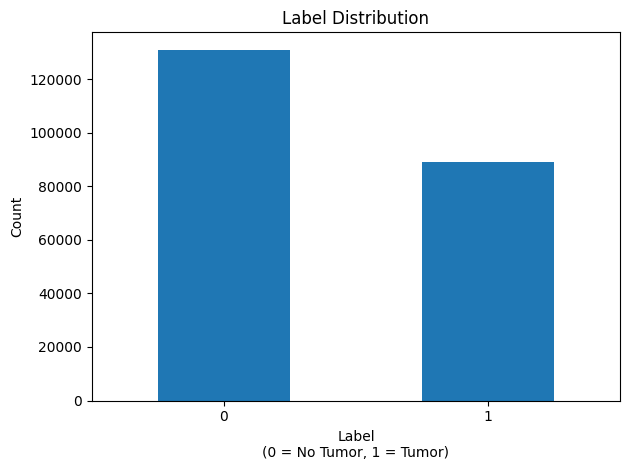

Label Percentage:


label
0    59.496875
1    40.503125
Name: count, dtype: float64

In [6]:
label_counts = train_labels["label"].value_counts().sort_index()

plt.figure()
label_counts.plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label\n(0 = No Tumor, 1 = Tumor)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

label_percentage = (label_counts / label_counts.sum()) * 100
print(f"Label Percentage:")
display(label_percentage)

Next as part of the EDA plot a subset of the TIFFs images from the the training set and test set. This will help visully see what the data looks.

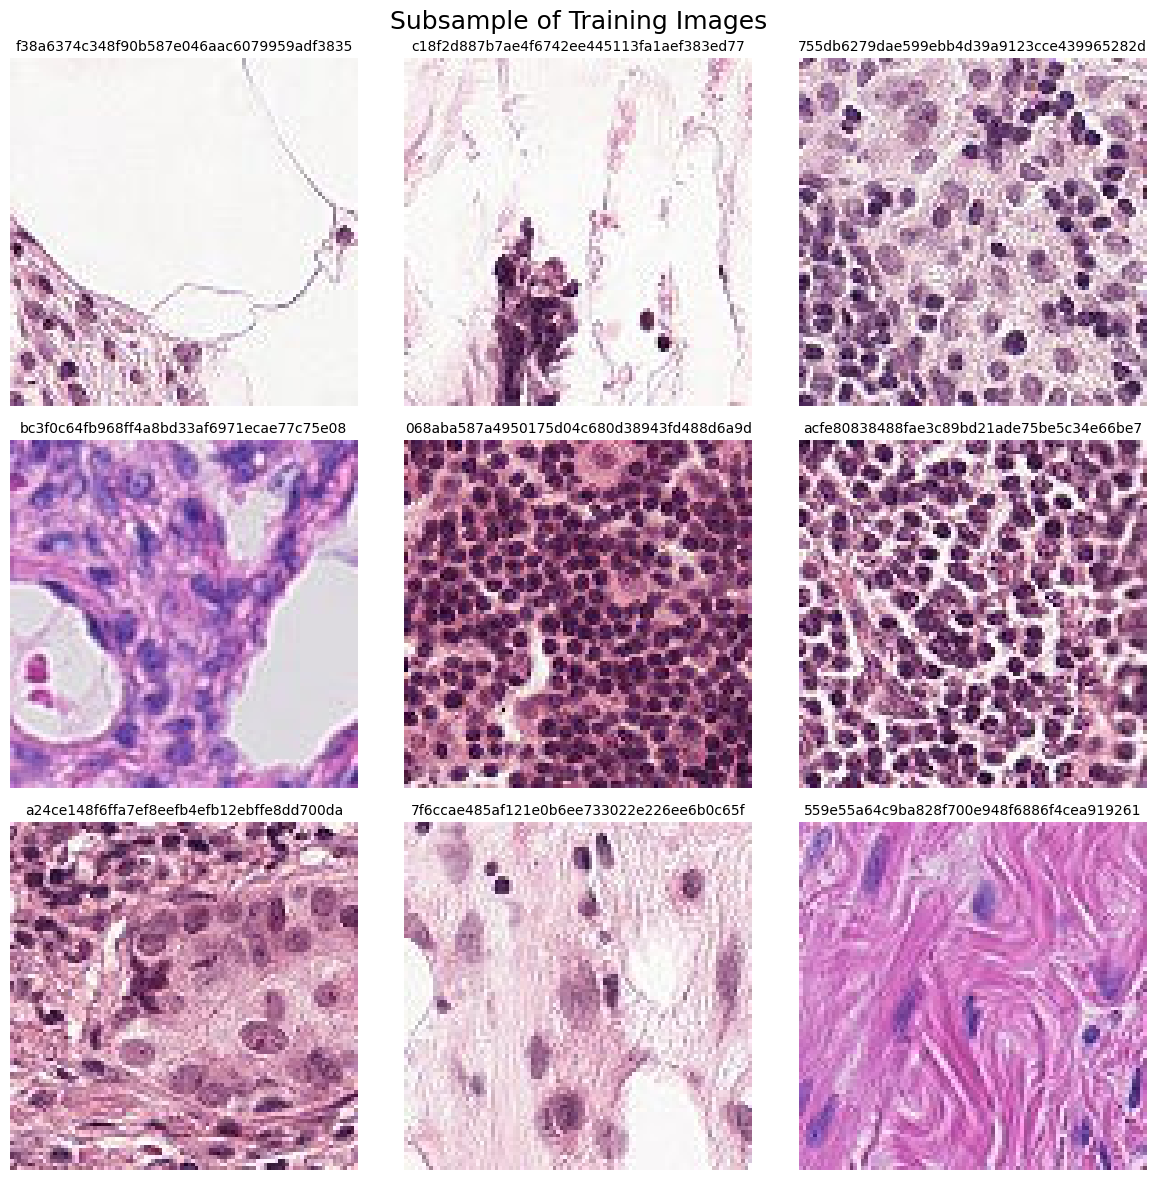

In [7]:
file_paths = []

for id in train_labels.head(9)["id"]:
    full_path = os.path.join(train_data_path, f"{id}.tif")
    file_paths.append(full_path)


n_imgs = len(file_paths)
cols = 3
rows = ceil(n_imgs / cols)
figsize = (4 * cols, 4 * rows)

fig, axes = plt.subplots(rows, cols, figsize=figsize)

fig.suptitle("Subsample of Training Images", fontsize=18)

axes = axes.ravel()

for idx, (ax, path) in enumerate(zip(axes, file_paths)):
    img = load_img(path)
    ax.imshow(img)
    ax.set_title(Path(path).stem, fontsize=10)
    ax.axis("off")

for ax in axes[n_imgs:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

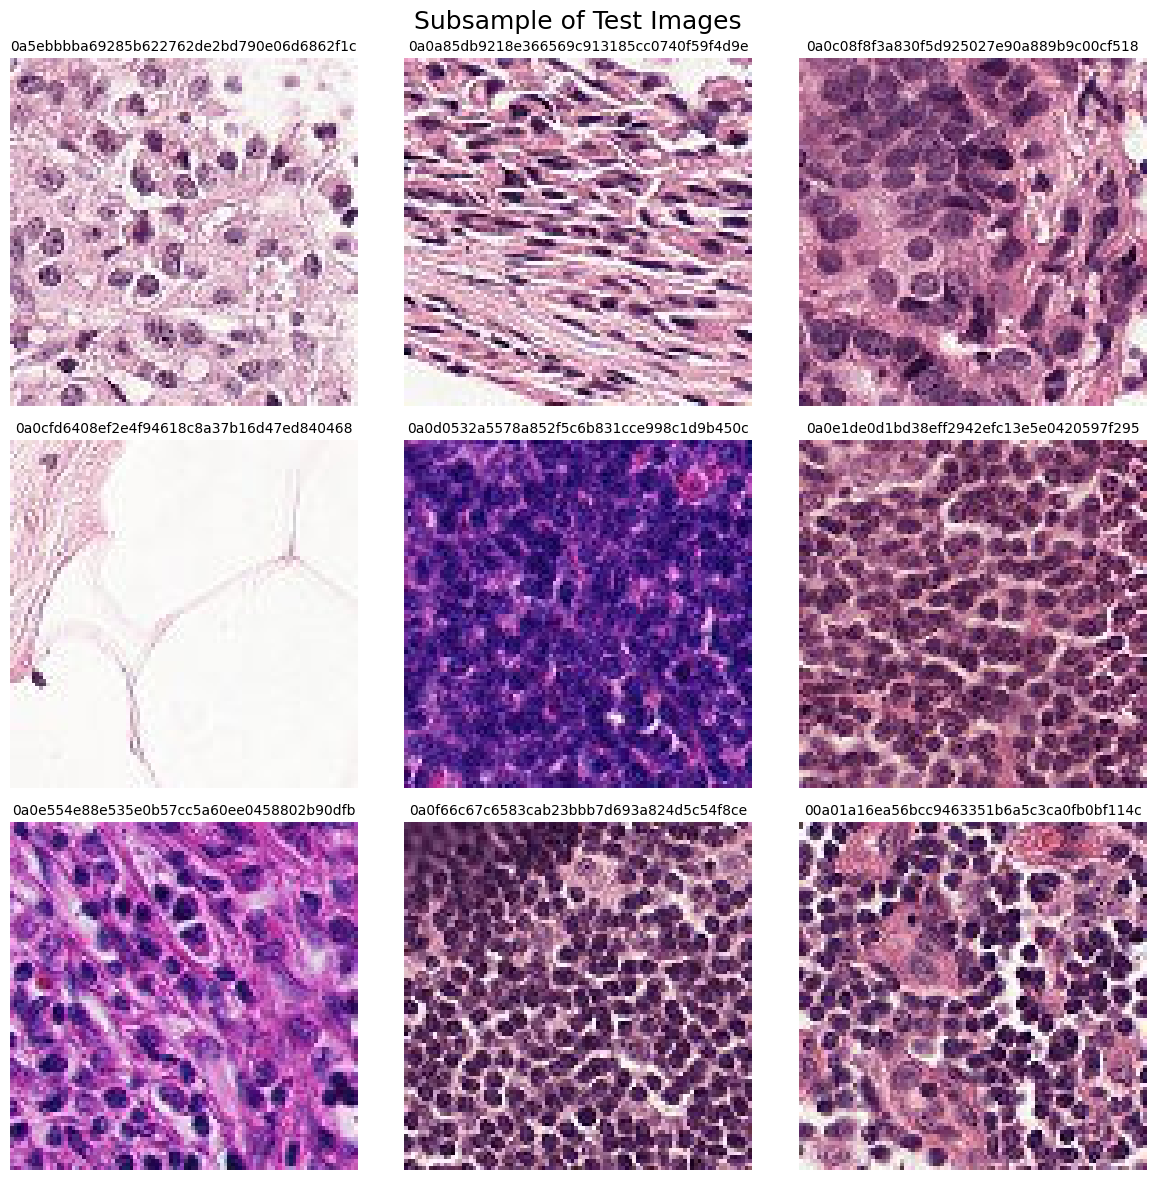

In [8]:
tiffs = ["0a5ebbbba69285b622762de2bd790e06d6862f1c.tif",
        "0a0a85db9218e366569c913185cc0740f59f4d9e.tif",
        "0a0c08f8f3a830f5d925027e90a889b9c00cf518.tif",
        "0a0cfd6408ef2e4f94618c8a37b16d47ed840468.tif",
        "0a0d0532a5578a852f5c6b831cce998c1d9b450c.tif",
        "0a0e1de0d1bd38eff2942efc13e5e0420597f295.tif",
        "0a0e554e88e535e0b57cc5a60ee0458802b90dfb.tif",
        "0a0f66c67c6583cab23bbb7d693a824d5c54f8ce.tif",
        "00a01a16ea56bcc9463351b6a5c3ca0fb0bf114c.tif"
        ]

file_paths = []


for tiff in tiffs:
    full_path = os.path.join(test_data_path, tiff)
    file_paths.append(full_path)

#display(file_paths)

n_imgs = len(file_paths)
cols = 3
rows = ceil(n_imgs / cols)
figsize = (4 * cols, 4 * rows)

fig, axes = plt.subplots(rows, cols, figsize=figsize)

fig.suptitle("Subsample of Test Images", fontsize=18)

axes = axes.ravel()

for idx, (ax, path) in enumerate(zip(axes, file_paths)):
    img = load_img(path)
    ax.imshow(img)
    ax.set_title(Path(path).stem, fontsize=10)
    ax.axis("off")

for ax in axes[n_imgs:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### 4. Prepare data from model training.

Since the Exploratory Data Analysis did not reveal and hidden bias or missing data in the dataset. There is not much data cleaning/preprocessing necessary. However, the dataset does need to be prepared before training a model can begin. For this a helper function is created to prepare the dataset. The prepare_dataset() function will iterate throug all labels in the dataset and build the image path directory to load the specific TIF image which is then append a list along with the label in a seprate list. The lists are then converated to a numpy array and returned.

In [9]:
def prepare_dataset(dataset:pd.DataFrame, image_dir:str, ):
    x = []
    y = []
    for idx, row in dataset.iterrows():
        img_path = os.path.join(image_dir, f"{row['id']}.tif")
        img = load_img(img_path, target_size=(64, 64))
        img_array = img_to_array(img) / 255.0
        x.append(img_array)
        y.append(row["label"])
    
    return np.array(x), np.array(y)
    
x, y = prepare_dataset(train_labels, train_data_path)

The next the step in preparing the dataset for traing a model is spliting the dataset into a training and testing subset of data. This is achieved with the function the train_test_split() which will split the main dataset into 80% training and 20% testing.

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### 4. Model 1 Architecture

For the first model I decied to keep it simple and build a CNN model  using TensorFlow's Keras API. It consisites of the following layers:

1. Input Layer

    * Accepts images of size (64, 64, 3) corresponding to 64x64 pixel color image (RGB)

2. First convolutional Block

    * Conv2D Layer: 32 filters, 3x3 kernel size, ReLU activation.
    * MaxPooling2D Layer: 2X2 pool size.
    * This allows the layer to extract basic low-level features from the images, such as edges, corners, and simple textures.

3. Second Convolutional Block

    * Conv2D Layer: 64 filters, 3x3 kernel size, ReLU activation.
    * MaxPooling2D Layer: 2x2 pool size.
    * Builds on the first layer to detect more complex patterns and textures by combining simple features.

4. Flatten Layer

    * Flattens the 2D feature maps into a 1D vector for the fully connected layers.

5. Fully Connected

    * Dense Layer: 128 units, ReLU activation.
    * Learns complex combinations of the extracted features to form high-level representations important for classification


In [11]:
image_size = 64

cnn_model_1 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(image_size, image_size, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

cnn_model_1.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

cnn_model_1.summary()

c:\Users\charlie\.envs\deep_learning_3_11\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,281 (6.20 MB)

 Trainable params: 1,625,281 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

After creating the CNN model call the fit() method on it to perfrom the training on the modle. The traing will use the training subset and train over 20 epochs with a batch_size of 32 and with a validation split of 20%

In [12]:
trained_cnn_model_1 = cnn_model_1.fit(x_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
4401/4401 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.7506 - loss: 0.5033 - val_accuracy: 0.8268 - val_loss: 0.3968
Epoch 2/20
4401/4401 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - accuracy: 0.8299 - loss: 0.3931 - val_accuracy: 0.8500 - val_loss: 0.3566
Epoch 3/20
4401/4401 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - accuracy: 0.8455 - loss: 0.3590 - val_accuracy: 0.8501 - val_loss: 0.3469
Epoch 4/20
4401/4401 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.8509 - loss: 0.3470 - val_accuracy: 0.8521 - val_loss: 0.3366
Epoch 5/20
4401/4401 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.8551 - loss: 0.3369 - val_accuracy: 0.8436 - val_loss: 0.3933
Epoch 6/20
4401/4401 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.8590 - loss: 0.3281 - val_accuracy: 0.8576 - val_loss: 0.3364
Epoch 7/20
4401/4401 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.8660 - loss: 0.3159 - val_accuracy: 0.8607 - val_loss: 0.3311
Epoch 8/20
4401/4401 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.8662 - loss: 0

After training the model the next step is to evaluate the performance of the trained model by using the test subset to score the accuracy of the model. The accuary of the model resulted a accuracy score of about 86.7%. Which is a relatively high score.

In [13]:
cnn_model_1_test_loss, cnn_model_1_test_acc = cnn_model_1.evaluate(x_test, y_test, verbose=2)

print(f"Test Acc: {cnn_model_1_test_acc:.3f}")

1376/1376 - 2s - 1ms/step - accuracy: 0.8643 - loss: 0.3540
Test Acc: 0.864


Next a plot of the training and validation accuracy over each epoch is plotted. This to aid in visualizing how the model learned over time. Based of the plot the model has good genralizaion since the validation accuracy raises with the training accuracy.

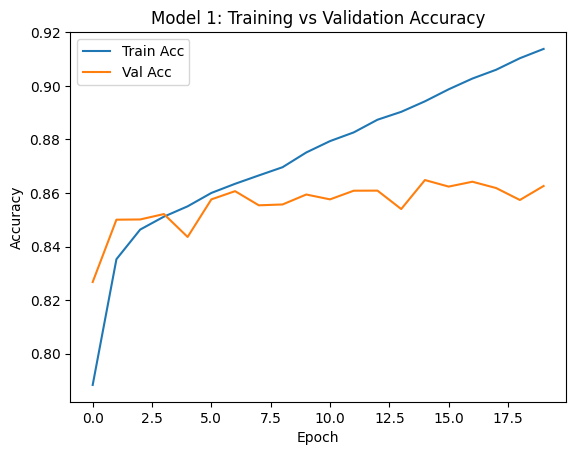

In [14]:
plt.plot(trained_cnn_model_1.history["accuracy"], label="Train Acc")
plt.plot(trained_cnn_model_1.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model 1: Training vs Validation Accuracy")
plt.show()

### Model 1 Tuning

In an effort to improve the accuary of the model, some tuning will be attempted. The following parameters were tuned in order to increase preformance:

* Increased the number filters doubling the capacity at each convolutional layer.
* Reduced dropout rate from 50% to 40% to keep more information while still controlling overfitting.
* Lowered the learning rate to make smaller, more precise weight updates from 0.001 -> 0.005.
* Added EarlyStopping to automatically stop training if validation loss does not improve, preventing overfitting and saving training time.


In [15]:
cnn_model_1_tuned = models.Sequential([
    layers.Conv2D(64, (3, 3), activation="relu", input_shape=(image_size, image_size, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

cnn_model_1_tuned.compile(optimizer=Adam(learning_rate=0.0005), loss="binary_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

cnn_model_1_tuned.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,287,169 (12.54 MB)

 Trainable params: 3,287,169 (12.54 MB)

 Non-trainable params: 0 (0.00 B)

After tuning the new CNN model call the fit() method on it to perfrom the training on the modle. The traing will use the training subset and train over 20 epochs with a batch_size of 32 and with a validation split of 20%

In [16]:
trained_cnn_model_1_tuned = cnn_model_1_tuned.fit(x_train, y_train, epochs=30, batch_size=64, validation_split=0.2, callbacks=[early_stop], verbose=2)

Epoch 1/30
2201/2201 - 64s - 29ms/step - accuracy: 0.7885 - loss: 0.4646 - val_accuracy: 0.8044 - val_loss: 0.4303
Epoch 2/30
2201/2201 - 63s - 29ms/step - accuracy: 0.8272 - loss: 0.3991 - val_accuracy: 0.8325 - val_loss: 0.3710
Epoch 3/30
2201/2201 - 64s - 29ms/step - accuracy: 0.8495 - loss: 0.3530 - val_accuracy: 0.8596 - val_loss: 0.3284
Epoch 4/30
2201/2201 - 64s - 29ms/step - accuracy: 0.8611 - loss: 0.3275 - val_accuracy: 0.8551 - val_loss: 0.3302
Epoch 5/30
2201/2201 - 64s - 29ms/step - accuracy: 0.8718 - loss: 0.3034 - val_accuracy: 0.8591 - val_loss: 0.3369
Epoch 6/30
2201/2201 - 63s - 28ms/step - accuracy: 0.8828 - loss: 0.2809 - val_accuracy: 0.8651 - val_loss: 0.3276
Epoch 7/30
2201/2201 - 63s - 29ms/step - accuracy: 0.8925 - loss: 0.2595 - val_accuracy: 0.8722 - val_loss: 0.3014
Epoch 8/30
2201/2201 - 63s - 28ms/step - accuracy: 0.9035 - loss: 0.2369 - val_accuracy: 0.8698 - val_loss: 0.3051
Epoch 9/30
2201/2201 - 62s - 28ms/step - accuracy: 0.9140 - loss: 0.2128 - val_a

Re-evaluate the accuracy on the testing subset to check if the tuning helped increasing the accuracy of the model. Based off the accuracy score of 87.9 there was a slightly improvement in the model after the tuning althought not by much.

In [17]:
cnn_model_1_tuned_test_loss, cnn_model_1_tuned_test_acc = cnn_model_1_tuned.evaluate(x_test, y_test, verbose=2)

print(f"Test Acc: {cnn_model_1_tuned_test_acc:.3f}")

1376/1376 - 4s - 3ms/step - accuracy: 0.8755 - loss: 0.2958
Test Acc: 0.875


Plot the Training vs Validation Accuracy plot.

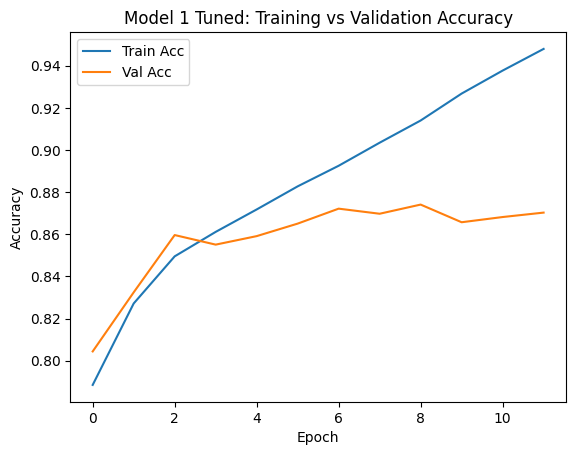

In [18]:
plt.plot(trained_cnn_model_1_tuned.history["accuracy"], label="Train Acc")
plt.plot(trained_cnn_model_1_tuned.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model 1 Tuned: Training vs Validation Accuracy")
plt.show()

### 5. Model 2 Architecture

For the second model I decied to design a slightly deeper CNN archiecture using TensorFlow's Keras API. It consisites of the following layers:

1. Inpute Layer:

    * Accepts images of (64, 64, 3), corresponding to 64x64 pixel color images (RGB).

2. First Convolutional Block:

    * Conv2D Layer: 16 filters, 3x3 kernel size, ReLU activation, "same" padding.
    * Conv2D Layer: 16 filters, 3x3 kernel size, ReLU activation, "same" padding.
    * MaxPooling2D Layer: 2x2 pool size.
    * This block allows the model to extract simple low-level features such as edges and textures, while maintaining the spatial dimensions due to "same" padding.

3. Second Convolutional Block:

    * Conv2D Layer: 32 filters, 3x3 kernel size, ReLU activation, "same" padding.
    * Conv2D Layer: 32 filters, 3x3 kernel size, ReLU activation, "same" padding.
    * MaxPooling2D Layer: 2x2 pool size.
    * This block builds on the first, enabling the model to detect more detailed features and patterns by combining simpler features.

4. Third Convolutional Block:

    * Conv2D Layer: 64 filters, 3x3 kernel size, ReLU activation, "same" padding.
    * MaxPooling2D Layer: 2x2 pool size.
    * This layer further deepens the model's understanding, capturing more abstract and high-level features important for classification.

5. Flatten Layer:

    * Flattens the 2D feature maps into a 1D vector in preparation for the fully connected layers.

6. Fully Connected Layer:
    * Dense Layer: 64 units, ReLU activation.
    * Dropout Layer: 30% dropout rate.
    * This layer learns complex relationships between features, while the Dropout regularizes the model to prevent overfitting.

7. Output Layer:

    * Dense Layer: 1 unit, Sigmoid activation.
    * Outputs a probability score for binary classification



In [19]:
cnn_model_2 = models.Sequential([

    layers.Conv2D(16, (3, 3), activation="relu", padding="same", input_shape=(image_size, image_size, 3)),
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

cnn_model_2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss="binary_crossentropy", metrics=["accuracy"])

cnn_model_2.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 297,425 (1.13 MB)

 Trainable params: 297,425 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

As perviously before after creating the CNN model call the fit() method on it to perfrom the training on the modle. The traing will use the training subset and train over 20 epochs with a batch_size of 32 and with a validation split of 20%

In [20]:
trained_cnn_model_2 = cnn_model_2.fit(x_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
4401/4401 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.5946 - loss: 0.6766 - val_accuracy: 0.6002 - val_loss: 0.6729
Epoch 2/20
4401/4401 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - accuracy: 0.5960 - loss: 0.6747 - val_accuracy: 0.6002 - val_loss: 0.6731
Epoch 3/20
4401/4401 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.5951 - loss: 0.6751 - val_accuracy: 0.6002 - val_loss: 0.6730
Epoch 4/20
4401/4401 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - accuracy: 0.5931 - loss: 0.6758 - val_accuracy: 0.6002 - val_loss: 0.6732
Epoch 5/20
4401/4401 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.5935 - loss: 0.6757 - val_accuracy: 0.6002 - val_loss: 0.6731
Epoch 6/20
4401/4401 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.5918 - loss: 0.6763 - val_accuracy: 0.6002 - val_loss: 0.6734
Epoch 7/20
4401/4401 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.5946 - loss: 0.6753 - val_accuracy: 0.6002 - val_loss: 0.6729
Epoch 8/20
4401/4401 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.5929 - loss: 0

After training the second model the next step is to evaluate the performance of the trained model by using the test subset to score the accuracy of the model. The accuary of the second model resulted a accuracy score of about 59.5%. Which is a significantly lower score than the first model. This maybe explained by several factors such as the second model utilized a smaller dense layer of 64 units afer extracting features, which limited its ability to combine information for final predictions. Also, the high learning rat of 0.005 likely casued unstable updates, which mostly likely perved the second model from converging properly.  

In [21]:
cnn_model_2_test_loss, cnn_model_2_test_acc = cnn_model_2.evaluate(x_test, y_test, verbose=2)

print(f"Test Acc: {cnn_model_2_test_acc:.3f}")

1376/1376 - 3s - 2ms/step - accuracy: 0.5949 - loss: 0.6750
Test Acc: 0.595


Plotting  the second models Training vs Validation Accuracy plot visually shows how the valdiation accuarcy did not converage or keep up the the training accuracy. As well as showing how the denser the model did not help it in increaseing the accuracy with the number epochs.

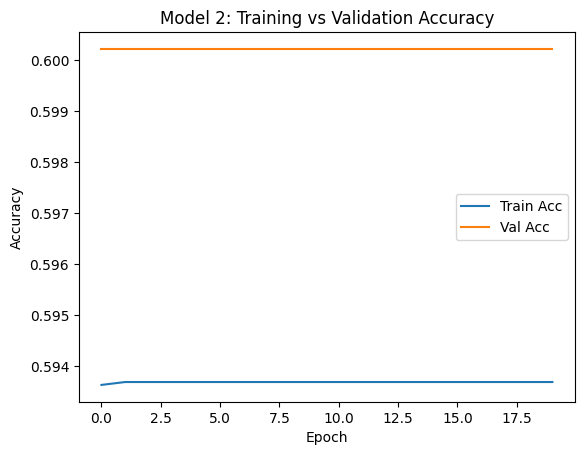

In [22]:
plt.plot(trained_cnn_model_2.history["accuracy"], label="Train Acc")
plt.plot(trained_cnn_model_2.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model 2: Training vs Validation Accuracy")
plt.show()

### Model 2 Tuning
In an effort to improve the accuary of the second model, some tuning will be attempted. The following parameters were tuned in order to increase preformance:

* Model depth was decreased to 2 convolutional blocks in an effort to simplify the second model to reduced overfitting risk.
* Dense Layer was increased to 128 units for stronger feature learning.
* The dropout rate was increased to 40% for better regularization.
* Earlystopping was added to stop training when validation loss plateuas.

In [23]:
cnn_model_2_tuned = models.Sequential([
    layers.Conv2D(16, (3, 3), activation="relu", padding="same", input_shape=(64,64,3)),
    layers.Conv2D(16, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

cnn_model_2_tuned.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss="binary_crossentropy", metrics=["accuracy"])

early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

cnn_model_2_tuned.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,065,489 (4.06 MB)

 Trainable params: 1,065,489 (4.06 MB)

 Non-trainable params: 0 (0.00 B)

After tuning fit the model withe testing subset as perviously done.

In [24]:
trained_cnn_model_2_tuned = cnn_model_2_tuned.fit(x_train, y_train, epochs=30, validation_split=0.2, callbacks=[early_stop], verbose=2)

Epoch 1/30
4401/4401 - 22s - 5ms/step - accuracy: 0.5935 - loss: 0.6760 - val_accuracy: 0.6002 - val_loss: 0.6731
Epoch 2/30
4401/4401 - 21s - 5ms/step - accuracy: 0.5937 - loss: 0.6756 - val_accuracy: 0.6002 - val_loss: 0.6729
Epoch 3/30
4401/4401 - 21s - 5ms/step - accuracy: 0.5937 - loss: 0.6756 - val_accuracy: 0.6002 - val_loss: 0.6733
Epoch 4/30
4401/4401 - 21s - 5ms/step - accuracy: 0.5937 - loss: 0.6756 - val_accuracy: 0.6002 - val_loss: 0.6730
Epoch 5/30
4401/4401 - 22s - 5ms/step - accuracy: 0.5937 - loss: 0.6756 - val_accuracy: 0.6002 - val_loss: 0.6729
Epoch 6/30
4401/4401 - 22s - 5ms/step - accuracy: 0.5937 - loss: 0.6756 - val_accuracy: 0.6002 - val_loss: 0.6731
Epoch 7/30
4401/4401 - 22s - 5ms/step - accuracy: 0.5937 - loss: 0.6756 - val_accuracy: 0.6002 - val_loss: 0.6731


Again evaluate the tuned second model to check of the tuning helped increase the accuracy score. However the accuracy score stayed the same at 59.5%. This could be due to the tuning changes were not impactfully enough for the model to have any increase/decrease in accuracy.

In [25]:
cnn_model_2_tuned_test_loss, cnn_model_2_tuned_test_acc = cnn_model_2_tuned.evaluate(x_test, y_test, verbose=2)

print(f"Test Acc: {cnn_model_2_tuned_test_acc:.3f}")

1376/1376 - 2s - 2ms/step - accuracy: 0.5949 - loss: 0.6750
Test Acc: 0.595


Plotting the Traning vs Validation Accuracy plot shows the same results as the original second model, which shows that the tuned hyperparameters were not impactfully enough to chagne the predictiveness of the model.

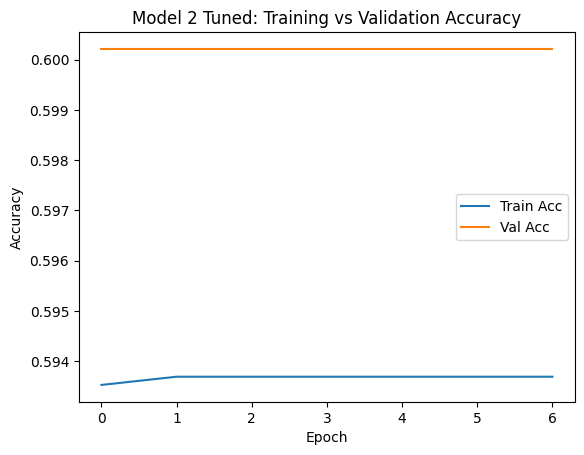

In [26]:
plt.plot(trained_cnn_model_2_tuned.history["accuracy"], label="Train Acc")
plt.plot(trained_cnn_model_2_tuned.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model 2 Tuned: Training vs Validation Accuracy")
plt.show()

In order to visually see how well each model performed a bar plot of all the modle accuracies was created. The bar plot shows that the second CNN model vs tuned model performed exactly the same. The bar chart also shows that the first tuned CNN model perfomred the best.

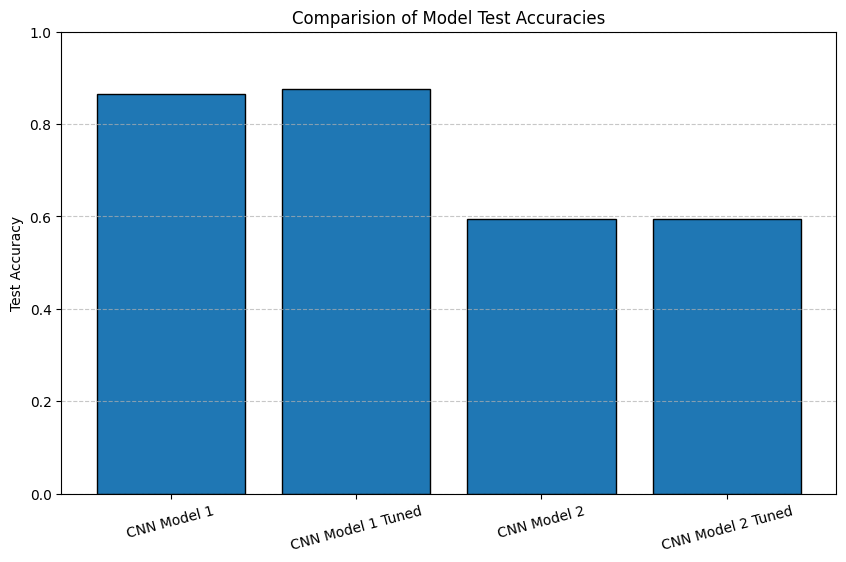

In [27]:
model_accs = [cnn_model_1_test_acc, cnn_model_1_tuned_test_acc, cnn_model_2_test_acc, cnn_model_2_tuned_test_acc]

model_names = ["CNN Model 1", "CNN Model 1 Tuned", "CNN Model 2", "CNN Model 2 Tuned"]

plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accs, edgecolor="black")
plt.ylim(0, 1)
plt.ylabel("Test Accuracy")
plt.title("Comparision of Model Test Accuracies")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=15)
plt.show()

### 6. Kaggle Resutls

Now that the modles have been tuned and trained that will be used to predict a labels for a seprate traning set of data. Fist, however in order to free up some resources the split training data will be deleted from memory.

In [28]:
del x_train, x_test, y_train, y_test
gc.collect()

11594

Next a helper fucntion is created to iterate and load all the test TIF images and then create a numpy array that the models can use to predict the labels.

In [29]:
def prepare_test_dataset(data_dir:str):
    x_test_new = []
    ids = []

    for file_name in os.listdir(data_dir):
        img_path = os.path.join(data_dir, file_name)
        img = load_img(img_path, target_size=(64,64))
        img_array = img_to_array(img) / 255.0
        x_test_new.append(img_array)
        ids.append(file_name.split(".")[0])

    return np.array(x_test_new), ids

x_test_new, ids = prepare_test_dataset(test_data_path)

The following code blocks will call each model that was trained and use the new testing dataset to predect the labels and create a pandas dataframe.

In [30]:
preds_model_1 = cnn_model_1.predict(x_test_new)
pred_labels_model_1 = (preds_model_1 > 0.5).astype(int).flatten()
cnn_model_1_results = pd.DataFrame({"id":ids, "label": pred_labels_model_1})

1796/1796 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [31]:
preds_model_1_tuned = cnn_model_1_tuned.predict(x_test_new)
pred_labels_model_1_tuned = (preds_model_1_tuned > 0.5).astype(int).flatten()
cnn_model_1_tuned_results = pd.DataFrame({"id": ids, "label": pred_labels_model_1_tuned})

1796/1796 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


In [32]:
preds_model_2 = cnn_model_2.predict(x_test_new)
pred_labels_model_2 = (preds_model_2 > 0.5).astype(int).flatten()
cnn_model_2_results = pd.DataFrame({"id": ids, "label": pred_labels_model_2})


1796/1796 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


In [33]:
preds_model_2_tuned = cnn_model_2_tuned.predict(x_test_new)
preds_labels_model_2_tuned = (preds_model_2_tuned > 0.5).astype(int).flatten()
cnn_model_2_tuned_results = pd.DataFrame({"id": ids, "label": preds_labels_model_2_tuned})

1796/1796 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


After all the models have predicted and created a pandas dataframe the dataframe will be saved locally as a csv. The csv will be submitted to kaggle for scoring.

In [34]:
preds_path = os.path.join(os.getcwd(), "model_preds")

cnn_model_1_results.to_csv(os.path.join(preds_path, "cnn_model_1.csv"), index=False)
cnn_model_1_tuned_results.to_csv(os.path.join(preds_path, "cnn_model_1_tuned.csv"), index=False)
cnn_model_2_results.to_csv(os.path.join(preds_path, "cnn_model_2.csv"), index=False)
cnn_model_2_tuned_results.to_csv(os.path.join(preds_path, "cnn_model_2_tuned.csv"), index=False)

### The following screenshot shows the results of each model on Kaggel. As expected the first model that was tuned scored the highest.
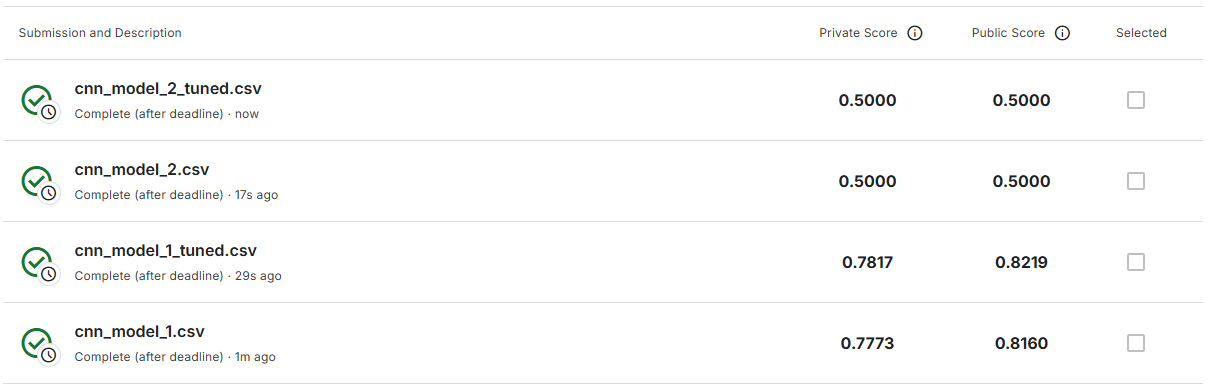

### Conclusion

Throughout the development and evaluation of multiple CNN architectures, several important learnings emerged. Simpler models with fewer convolutional layers and moderately sized dense layers, such as the first original model, achieved better performance compared to deeper, more complex models like the second original model. This highlighted that for relatively small datasets, deeper architectures with many convolutional layers may not generalize well without sufficient data and tuning. Tuning efforts, such as increasing the number of filters, adjusting dropout rates, adding EarlyStopping, and enlarging the dense layers, generally helped improve the models' generalization and stability. However, extremely high learning rates, as used in the second model, did not significantly benefit performance and may have hindered convergence. In the future, improvements could include applying data augmentation to artificially expand the training set, using more sophisticated regularization techniques like batch normalization, exploring learning rate scheduling, and experimenting with pre-trained models through transfer learning to leverage previously learned features. Overall, this project reinforced the importance of matching model complexity to dataset size and carefully tuning hyperparameters to optimize model performance.

### Refrences

1. [Histopathologic Cancer Detection](https://www.kaggle.com/competitions/histopathologic-cancer-detection/data)
2. [Tensorflow Docs](https://www.tensorflow.org/api_docs/python/tf/all_symbols)
3. [Keras API Docs](https://keras.io/api/)
4. [Tensorflow CNN Tutorial](https://www.tensorflow.org/tutorials/images/cnn)

### Github Repo

https://github.com/charliearvizu-edu/cnn_cancer_detection/tree/dev